In [17]:
# from google.colab import drive
# drive.flush_and_unmount()

In [1]:
!pip install nltk

import pandas as pd
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import TreebankWordTokenizer
from nltk import pos_tag
from nltk.corpus import wordnet

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

desired_width = 200
pd.set_option('display.width', desired_width)
pd.set_option('display.max_columns', 20)

# from google.colab import drive
# drive.mount('/content/drive')
# metadata = pd.read_csv(r'/content/drive/My Drive/Colab Notebooks/metadata.csv', low_memory=False)
metadata = pd.read_csv(r'metadata.csv', low_memory=False)

print(metadata.columns)
print('\n',metadata.describe)
print('\n',metadata.shape)

[nltk_data] Downloading package wordnet to /home/santhraj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/santhraj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/santhraj/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/santhraj/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Index(['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time', 'authors', 'journal', 'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files',
       'pmc_json_files', 'url', 's2_id'],
      dtype='object')

 <bound method NDFrame.describe of          cord_uid                                                sha                source_x                                              title                           doi       pmcid pubmed_id  \
0        ug7v899j           d1aafb70c066a2068b02786f8929fd9c900897fb                     PMC  Clinical features of culture-proven Mycoplasma...         10.1186/1471-2334-1-6    PMC35282  11472636   
1        02tnwd4m           6b0567729c2143a66d737eb0a2f63f2dce2e5a7d                     PMC  Nitric oxide: a pro-inflammatory mediator in l...                  10.1186/rr14    PMC59543  11667967   
2        ejv2xln0           06ced00a5fc04215949aa72528f2eeaae1d58927                     PMC    Surfactant

In [2]:
metadata = metadata[['title', 'abstract']]

In [3]:
# Checking if there are Null Values
metadata.isnull().sum()

title          503
abstract    235544
dtype: int64

In [4]:
# Dropping entire rows where there are Null Values present in title and abstract columns.
metadata.dropna(subset=['title', 'abstract'], how='all', inplace=True)
metadata.dropna(subset=['abstract'], inplace=True)
metadata.dropna(subset=['title'], inplace=True)
metadata.reset_index(drop=True, inplace=True)

# Cross checking
metadata.isnull().sum()

title       0
abstract    0
dtype: int64

In [5]:
# Data cleaning
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
tokenizer = TreebankWordTokenizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_text(text):
    if pd.isnull(text):
        return ""

    # Lowercasing text
    text = str(text).lower()

    # Removing the punctuations and numbers
    text = re.sub(r'\W+', ' ', text)

    # Tokenization
    tokens = tokenizer.tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    try:
        tagged_tokens = pos_tag(tokens)
    except:
        tagged_tokens = [(t, 'NN') for t in tokens]

    # Lemmatization
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in tagged_tokens]
    return ' '.join(lemmatized)

In [9]:
%pip install swifter
import swifter

metadata['cleaned_title'] = metadata['title'].swifter.apply(clean_text)
metadata['cleaned_abstract'] = metadata['abstract'].swifter.apply(clean_text)

Note: you may need to restart the kernel to use updated packages.


/home/santhraj/miniconda3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Pandas Apply: 100%|██████████| 821005/821005 [11:52<00:00, 1152.97it/s]


In [15]:
# Saving the Cleaned Dataset to Drive
# metadata.to_csv('/content/drive/My Drive/Colab Notebooks/cleaned_metadata.csv', index=False)
metadata.to_csv('cleaned_metadata.csv', index=False)

In [16]:
cleaned_metadata = pd.read_csv(
    'cleaned_metadata.csv',
    low_memory=False,
    quotechar='"',
    quoting=0,  # or csv.QUOTE_MINIMAL
    on_bad_lines='warn'  # or 'skip' to ignore bad rows
)

print(cleaned_metadata.columns)
print('\n', cleaned_metadata.describe())
print('\n', cleaned_metadata.shape)


Index(['title', 'abstract', 'cleaned_title', 'cleaned_abstract'], dtype='object')

                                            title             abstract                        cleaned_title      cleaned_abstract
count                                     821005               821005                               820982                820782
unique                                    677668               730632                               606073                659020
top     ACR Convergence 2020 Abstract Supplement  [Figure: see text].  acr convergence abstract supplement  corrects article doi
freq                                          99                  206                                  100                   383

 (821005, 4)


# Feature Extraction

In [17]:
#TF-IDF
# %pip install scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer


# Taking a random sample of 10,000 cleaned abstracts
sample_df = cleaned_metadata.sample(10000, random_state=42)

# Making sure that each entry is a string (in case it's a list or something else)
sample_df['cleaned_abstract_str'] = sample_df['cleaned_abstract'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x))

#initialize tf-idf vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95)

#fit the vectorizer to cleaner data and trasnform the text into a sparse matrix
X_tfidf_sample = vectorizer.fit_transform(sample_df['cleaned_abstract_str'])

#output shape of TF-IDF matrix (documents x features), this will give you the number of documents and unique words
print("TF-IDF matrix shape (sample):", X_tfidf_sample.shape)

#print first 10 words/features
print("First 10 words in vocabulary:", vectorizer.get_feature_names_out()[:10])

#converting it to an array for optional use, otherwise we can use X_tfidf
tfidf_sample_array = X_tfidf_sample.toarray()

#displaying first 5 rows of the TF-IDF matrix array
print("TF-IDF array (first 5 rows):\n", tfidf_sample_array[:5])

TF-IDF matrix shape (sample): (10000, 49477)
First 10 words in vocabulary: ['aa' 'aaa' 'aaag' 'aaauuuu' 'aab' 'aacpd' 'aacpdes' 'aad' 'aadhaar'
 'aado']
TF-IDF array (first 5 rows):
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [18]:
# Bert embeddings
# %pip install transformers torch
# %pip install pandas


# cleaned_metadata = pd.read_csv('/content/drive/My Drive/Colab Notebooks/cleaned_metadata.csv')
cleaned_metadata = pd.read_csv('cleaned_metadata.csv')
sample_df = cleaned_metadata.sample(10000, random_state=42)

from transformers import BertTokenizer, BertModel
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


#Loading pre-trained Bert model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.to(device)

#initializing list to store embeddings for each document
bert_embeddings = []

#iterate through cleaned abstracts in metadata (dataframe)
for abstract in sample_df['cleaned_abstract']:
  #tokenize the abstract
  abstract = str(abstract) if pd.notnull(abstract) else ""

  inputs = tokenizer(abstract, return_tensors='pt', padding=True, truncation=True, max_length=512)
  inputs = {k: v.to(device) for k, v in inputs.items()}

  #passing the tokenized input through bert (no gradient cal. reqd.)
  with torch.no_grad():
    outputs = model(**inputs)

  #extracting the embedding for the [CLS] token (represents the whole document). CLS is a special token in bert to represent the entire input sequence for classification tasks. It's placed at the beginning of the input sequence and its final output embedding captures the overall meaning or sentiment of the text
  cls_embedding = outputs.last_hidden_state[0][0]

  #appending the [CLS] token embedding (which is a 768 dimensional vector)
  bert_embeddings.append(cls_embedding.cpu()) #convertin to numpy for easier manipulation

#converting it to an array
bert_embeddings_array = torch.stack(bert_embeddings).numpy()

#printing shape of bert embeddings array (documents x 768)
print('BERT embeddings shape: ', bert_embeddings_array.shape)

#displaying the bert embedding for the first document
print("BERT embedding for document 1: ", bert_embeddings_array[0])

np.save('bert_embeddings_10k.npy', bert_embeddings_array)


#Use the following for modelling
#TF-IDF - X_tfidf
#BERT embeddings - bert_embeddings_array


Using device: cpu


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


BERT embeddings shape:  (10000, 768)
BERT embedding for document 1:  [-3.94264460e-01  5.72401509e-02  3.05300921e-01  8.38465765e-02
 -1.92825809e-01  6.15764223e-02  2.93501820e-02  1.19972199e-01
 -2.34787688e-01 -2.28632599e-01  7.09137600e-03 -4.40961659e-01
 -2.28192940e-01  2.55327553e-01 -2.22707137e-01  2.69589931e-01
  1.01381284e-03  2.88876176e-01 -5.05900532e-02  1.23911299e-01
 -1.92205682e-01 -4.98139918e-01  5.65166116e-01 -1.53788924e-01
 -1.41386494e-01 -4.49169099e-01  4.11511287e-02  1.86638176e-01
 -4.64597717e-02  1.05594723e-02  2.47923136e-01  1.28246054e-01
 -1.12020731e-01  1.01724705e-02  1.23525947e-01 -2.70563811e-01
  2.01601923e-01  4.53574173e-02  4.40435588e-01  9.72909182e-02
 -8.36588442e-02  7.16866702e-02  2.48335212e-01 -1.94843709e-02
  1.19040005e-01 -3.22328061e-02 -3.15548182e+00  2.06413686e-01
 -1.87873378e-01 -9.29145366e-02  5.21303594e-01 -3.27358723e-01
  1.37458056e-01  4.12572891e-01 -2.08343595e-01  3.08278292e-01
 -2.94719525e-02 -1.2

In [19]:
# K-Means clustering on TF-IDF and BERT embeddings
# %pip install matplotlib
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
bert_embeddings_array = np.load('bert_embeddings_10k.npy')
# Number of clusters (topics)
num_clusters = 10
random_seed = 42

# K-Means on TF-IDF
kmeans_tfidf = KMeans(n_clusters=num_clusters, random_state=random_seed)
sample_df['tfidf_topic'] = kmeans_tfidf.fit_predict(X_tfidf_sample)

# Top terms per cluster (optional)
terms = vectorizer.get_feature_names_out()
print("\nTop TF-IDF terms per cluster:")
for i in range(num_clusters):
    center = kmeans_tfidf.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    print(f"Cluster {i}: {[terms[ind] for ind in top_indices]}")

# K-Means on BERT embeddings
kmeans_bert = KMeans(n_clusters=num_clusters, random_state=random_seed)
sample_df['bert_topic'] = kmeans_bert.fit_predict(bert_embeddings_array)

# Cluster counts for comparison
print("\nCluster distribution (TF-IDF):")
print(sample_df['tfidf_topic'].value_counts().sort_index())

print("\nCluster distribution (BERT):")
print(sample_df['bert_topic'].value_counts().sort_index())


Top TF-IDF terms per cluster:
Cluster 0: ['care', 'patient', 'health', 'covid', 'pandemic', 'service', 'healthcare', 'hospital', 'staff', 'cancer']
Cluster 1: ['pandemic', 'covid', 'health', 'social', 'research', 'public', 'policy', 'economic', 'country', 'food']
Cluster 2: ['student', 'learning', 'education', 'teaching', 'online', 'school', 'teacher', 'university', 'pandemic', 'course']
Cluster 3: ['cell', 'protein', 'virus', 'viral', 'immune', 'vaccine', 'infection', 'gene', 'binding', 'sars']
Cluster 4: ['cov', 'sars', 'covid', 'infection', 'coronavirus', 'respiratory', 'virus', 'syndrome', 'severe', 'antibody']
Cluster 5: ['mental', 'health', 'covid', 'anxiety', 'pandemic', 'participant', 'psychological', 'depression', 'social', 'study']
Cluster 6: ['patient', 'study', 'treatment', 'group', 'disease', 'covid', 'method', 'result', 'clinical', 'using']
Cluster 7: ['patient', 'covid', 'disease', 'severe', 'clinical', 'mortality', 'hospital', 'ci', 'day', 'infection']
Cluster 8: ['la'

Note: you may need to restart the kernel to use updated packages.


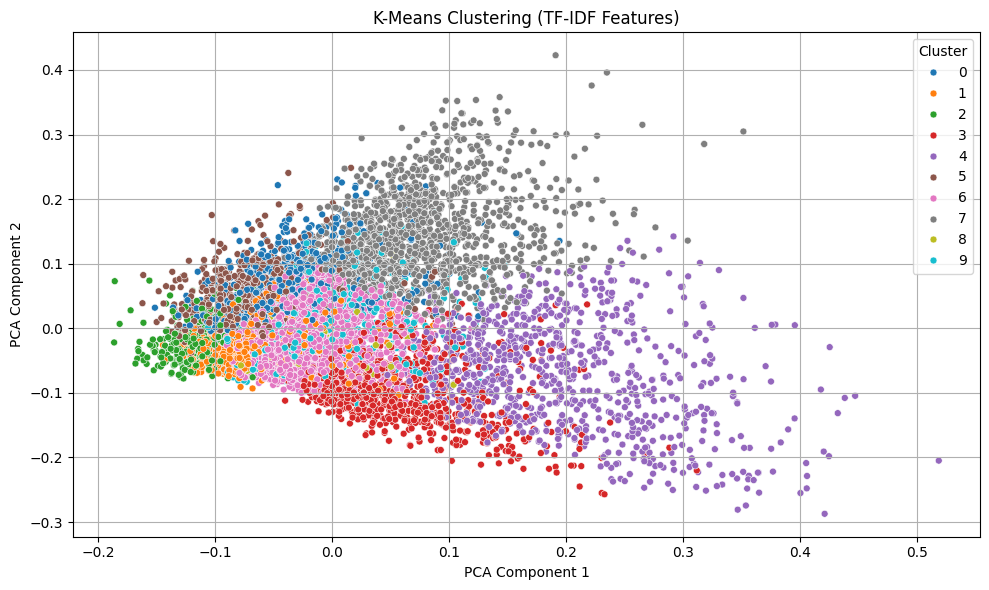

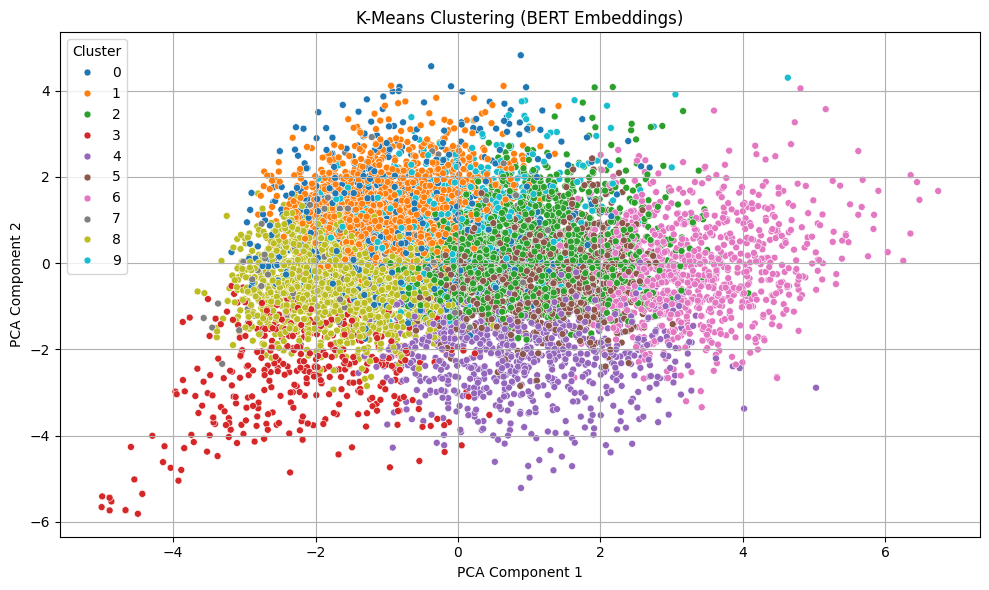

In [20]:
%pip install seaborn
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce TF-IDF vectors to 2D
pca_tfidf = PCA(n_components=2, random_state=42)
tfidf_2d = pca_tfidf.fit_transform(X_tfidf_sample.toarray())

# Reduce BERT embeddings to 2D
pca_bert = PCA(n_components=2, random_state=42)
bert_2d = pca_bert.fit_transform(bert_embeddings_array)

# Plot TF-IDF Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tfidf_2d[:, 0], y=tfidf_2d[:, 1], hue=sample_df['tfidf_topic'], palette="tab10", s=25)
plt.title('K-Means Clustering (TF-IDF Features)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot BERT Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=bert_2d[:, 0], y=bert_2d[:, 1], hue=sample_df['bert_topic'], palette="tab10", s=25)
plt.title('K-Means Clustering (BERT Embeddings)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.


/home/santhraj/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


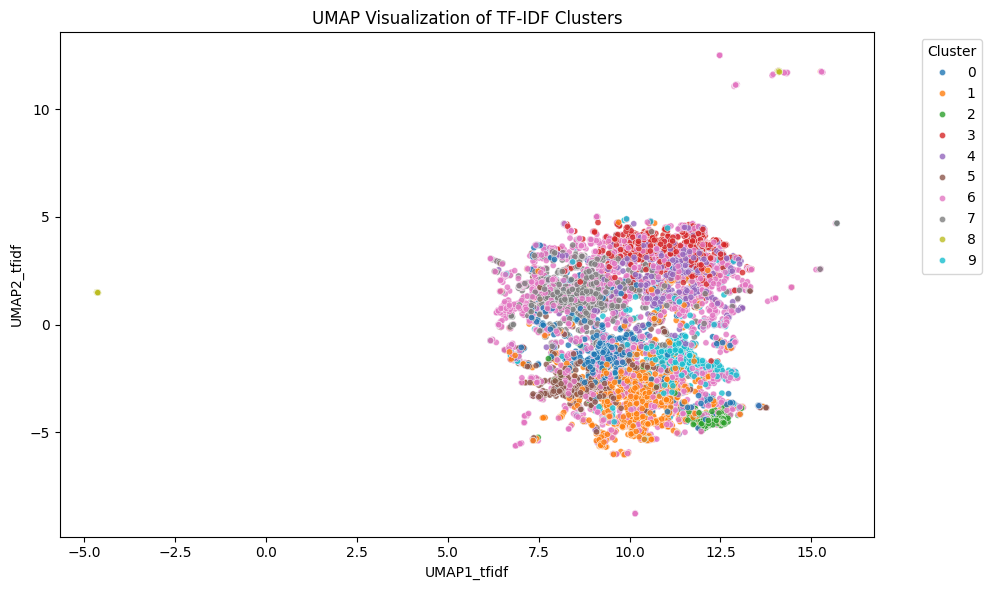

In [21]:
# UMAP Visualization for TF-IDF
%pip install umap-learn

import umap
import seaborn as sns
import matplotlib.pyplot as plt

# Reduce TF-IDF vectors to 2D using UMAP
umap_tfidf = umap.UMAP(n_neighbors=10, min_dist=0.05, n_components=2, random_state=42)
tfidf_2d = umap_tfidf.fit_transform(tfidf_sample_array)

# Add UMAP results to DataFrame for plotting
sample_df['UMAP1_tfidf'] = tfidf_2d[:, 0]
sample_df['UMAP2_tfidf'] = tfidf_2d[:, 1]

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='UMAP1_tfidf', y='UMAP2_tfidf',
    hue='tfidf_topic',
    palette='tab10',
    data=sample_df,
    s=20, alpha=0.8
)
plt.title("UMAP Visualization of TF-IDF Clusters")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/home/santhraj/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


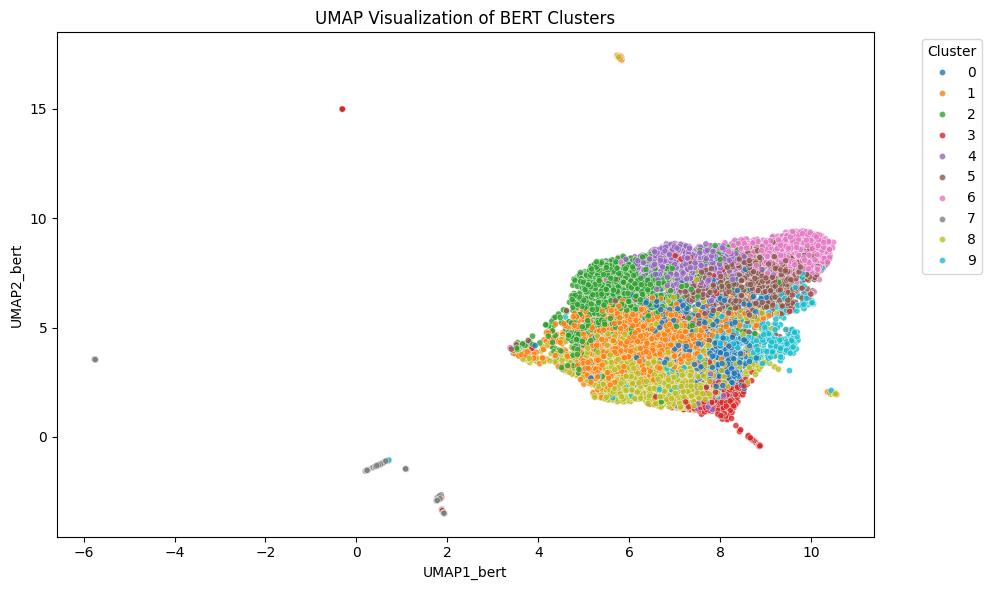

In [22]:
# UMAP Visualization for BERT
umap_bert = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
bert_2d = umap_bert.fit_transform(bert_embeddings_array)

# Add UMAP results to DataFrame for plotting
sample_df['UMAP1_bert'] = bert_2d[:, 0]
sample_df['UMAP2_bert'] = bert_2d[:, 1]

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='UMAP1_bert', y='UMAP2_bert',
    hue='bert_topic',
    palette='tab10',
    data=sample_df,
    s=20, alpha=0.8
)
plt.title("UMAP Visualization of BERT Clusters")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# LDA

In [18]:
pip install gensim pyLDAvis wordcloud matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.9/547.9 kB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 4.5 MB/s eta 0:00:0000:0100:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 5.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 4.1 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━

In [23]:
# Replace NaN with empty string and ensure all values are strings
cleaned_metadata['cleaned_abstract'] = cleaned_metadata['cleaned_abstract'].fillna('').astype(str)

# Now safely split into words
texts = [doc.split() for doc in cleaned_metadata['cleaned_abstract']]

In [24]:
from gensim.corpora import Dictionary
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

In [ ]:
from gensim.models import LdaModel

lda_model = LdaModel(corpus=corpus,
                     id2word=dictionary,
                     num_topics=10,
                     random_state=42,
                     passes=10)

In [17]:
for idx, topic in lda_model.print_topics(-1):
    print(f"\nTopic {idx + 1}: {topic}")


Topic 1: 0.023*"cell" + 0.015*"disease" + 0.009*"immune" + 0.008*"treatment" + 0.008*"response" + 0.007*"inflammatory" + 0.007*"infection" + 0.006*"lung" + 0.006*"expression" + 0.006*"effect"

Topic 2: 0.020*"care" + 0.017*"patient" + 0.011*"covid" + 0.010*"study" + 0.009*"health" + 0.008*"pandemic" + 0.007*"review" + 0.007*"clinical" + 0.007*"healthcare" + 0.007*"service"

Topic 3: 0.020*"covid" + 0.016*"health" + 0.013*"pandemic" + 0.013*"coronavirus" + 0.010*"study" + 0.008*"social" + 0.005*"student" + 0.005*"result" + 0.005*"participant" + 0.005*"impact"

Topic 4: 0.021*"model" + 0.011*"data" + 0.011*"based" + 0.011*"method" + 0.011*"covid" + 0.008*"using" + 0.007*"system" + 0.007*"result" + 0.007*"used" + 0.006*"time"

Topic 5: 0.049*"sars" + 0.030*"infection" + 0.028*"vaccine" + 0.024*"virus" + 0.018*"respiratory" + 0.016*"antibody" + 0.015*"viral" + 0.014*"vaccination" + 0.010*"disease" + 0.010*"pcr"

Topic 6: 0.047*"patient" + 0.039*"covid" + 0.027*"cov" + 0.019*"p" + 0.012*"s

In [18]:
dominant_topics = []
for bow in corpus:
    topic_probs = lda_model.get_document_topics(bow)
    dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
    dominant_topics.append(dominant_topic)

metadata['dominant_topic'] = dominant_topics

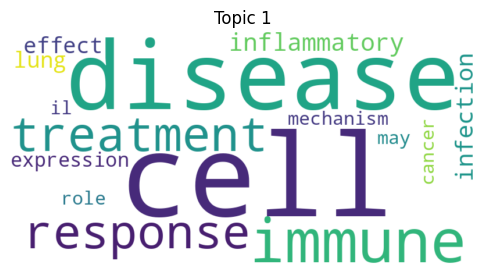

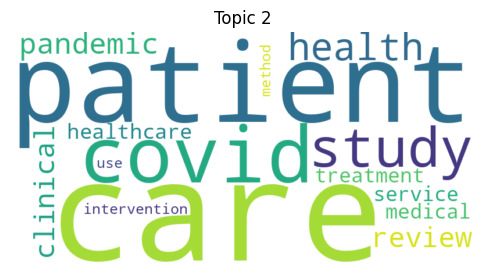

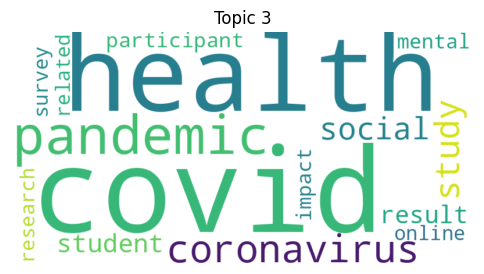

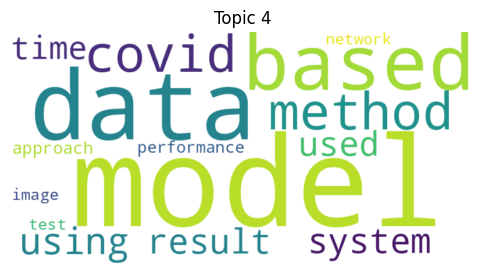

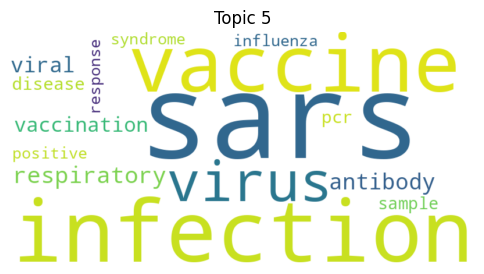

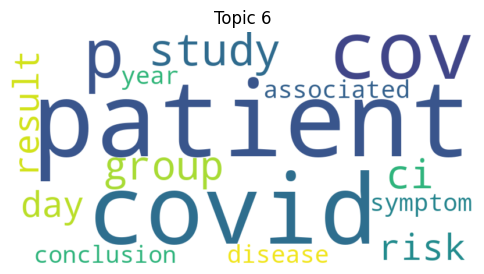

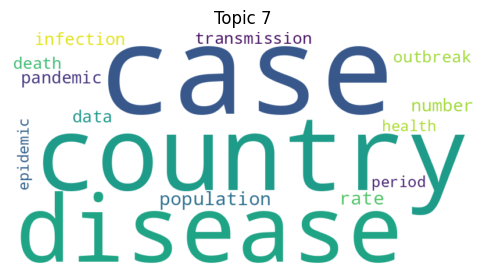

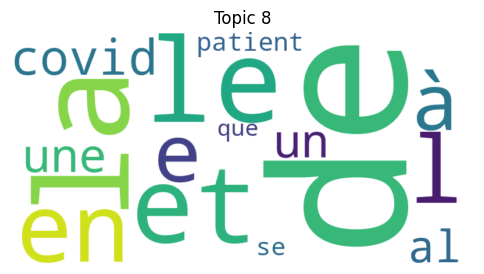

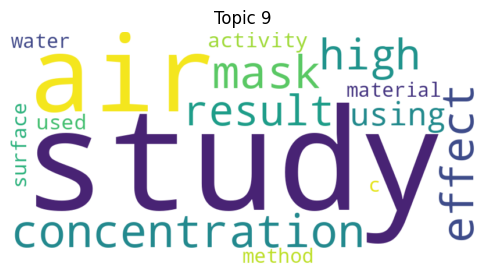

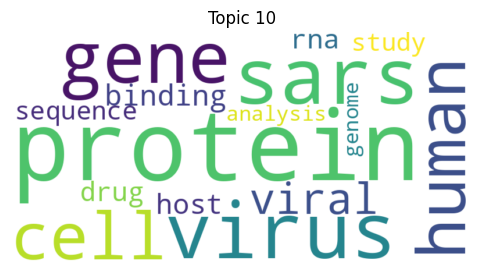

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for i in range(10):
    plt.figure(figsize=(6,4))
    words = dict(lda_model.show_topic(i, topn=15))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(words)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Topic {i + 1}")
    plt.show()

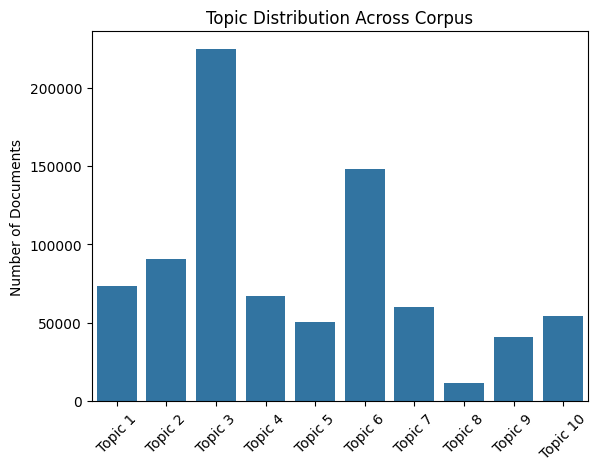

In [24]:
import seaborn as sns

topic_counts = metadata['dominant_topic'].value_counts().sort_index()
sns.barplot(x=[f"Topic {i+1}" for i in topic_counts.index], y=topic_counts.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Documents")
plt.title("Topic Distribution Across Corpus")
plt.show()

In [26]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Get topic-word distributions
num_topics = 10
vocab_size = len(dictionary)
topic_word_matrix = np.zeros((num_topics, vocab_size))

# Fill the matrix
for i in range(num_topics):
    topic_terms = lda_model.get_topic_terms(i, topn=vocab_size)
    for term_id, weight in topic_terms:
        topic_word_matrix[i, term_id] = weight

# Compute similarity
similarity = cosine_similarity(topic_word_matrix)

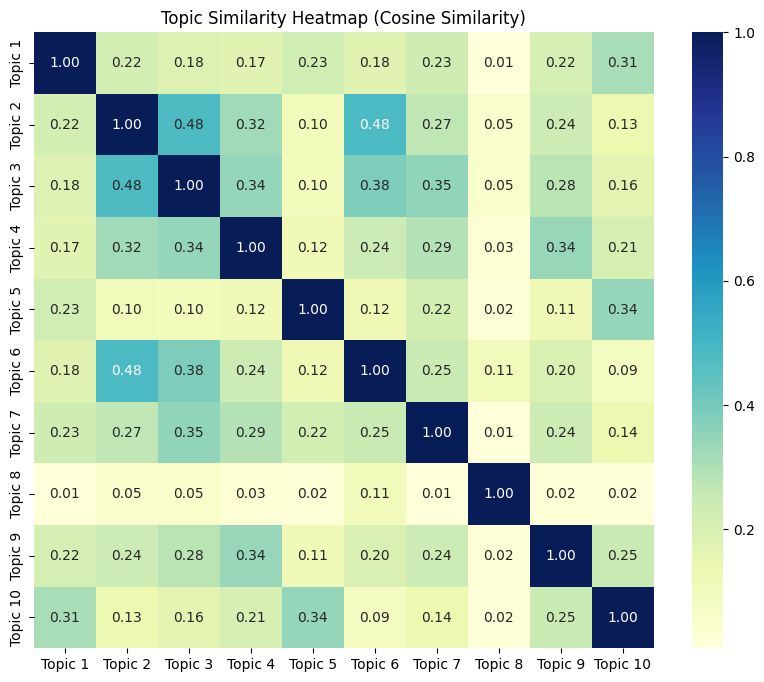

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(similarity, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=[f"Topic {i+1}" for i in range(num_topics)],
            yticklabels=[f"Topic {i+1}" for i in range(num_topics)])
plt.title("Topic Similarity Heatmap (Cosine Similarity)")
plt.show()

In [ ]:
from sklearn.manifold import TSNE

# Get document-topic matrix
topic_distributions = np.array([
    [prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
    for bow in corpus
])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(topic_distributions)

plt.figure(figsize=(10,6))
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=metadata['dominant_topic'], palette='tab10', legend='full')
plt.title("2D Topic Visualization using t-SNE")
plt.show()

In [ ]:
import gensim
# Save dictionary
dictionary.save('lda_dictionary.dict')
metadata.to_csv('metadata_with_topics.csv', index=False)
# Save model
lda_model.save('lda_model.gensim')

# Save corpus (if needed)
gensim.corpora.MmCorpus.serialize('lda_corpus.mm', corpus)

# NMF

Index(['title', 'abstract', 'cleaned_title', 'cleaned_abstract'], dtype='object')

                                                title abstract                                      cleaned_title cleaned_abstract
count                                          10000    10000                                              10000            10000
unique                                          9969     9970                                               9958             9950
top     Dissecting the early COVID-19 cases in Wuhan  Unknown  validating implementing cardiac telemetry cont...  figure see text
freq                                               2        4                                                  2                7

 (10000, 4)
Topic 1: impact,healthcare,service,research,public,social,care,pandemic,covid,health
Topic 2: antibody,acute,severe,virus,syndrome,coronavirus,respiratory,infection,cov,sars
Topic 3: cancer,symptom,care,severe,treatment,hospital,clinical,disease,covid,p

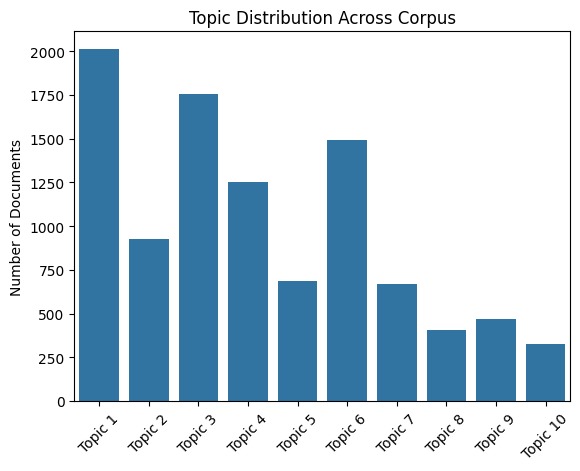

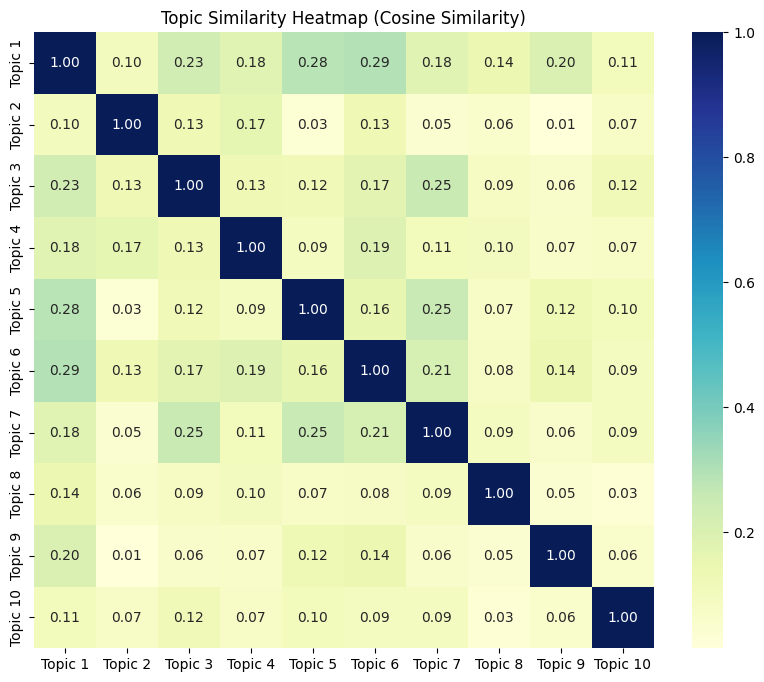

Saved: nmf_model.pkl, tfidf_vectorizer.pkl, sample_with_topics.csv


In [16]:
# NMF ("Non-Negative Matrix Factorization") with saving for future use

from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import seaborn as sns

# Sample 10,000 rows
sample_df = cleaned_metadata.sample(10000, random_state=42)

print(sample_df.columns)
print('\n', sample_df.describe())
print('\n', sample_df.shape)

# Ensure cleaned_abstract_str is a string
sample_df['cleaned_abstract_str'] = sample_df['cleaned_abstract'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

# Vectorize text
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95)
X_tfidf_sample = vectorizer.fit_transform(sample_df['cleaned_abstract_str'])
words = np.array(vectorizer.get_feature_names_out())

# Fit NMF
nmf = NMF(n_components=10, solver="mu", random_state=42)  # Reduced to 10 topics for practicality
W = nmf.fit_transform(X_tfidf_sample)
H = nmf.components_

# Top 10 words per topic
for i, topic in enumerate(H):
    print("Topic {}: {}".format(i + 1, ",".join([str(x) for x in words[topic.argsort()[-10:]]])))

# Assign dominant topic
topic_distribution = W  # Reuse W instead of refitting
sample_df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Add topic distributions as columns
topic_df = pd.DataFrame(topic_distribution, columns=[f'Topic_{i+1}' for i in range(nmf.n_components)])
sample_df = pd.concat([sample_df.reset_index(drop=True), topic_df.reset_index(drop=True)], axis=1)

# Plot topic frequencies
topic_counts = sample_df['dominant_topic'].value_counts().sort_index()
sns.barplot(x=[f"Topic {i+1}" for i in topic_counts.index], y=topic_counts.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Documents")
plt.title("Topic Distribution Across Corpus")
plt.show()

# Plot topic similarity heatmap
similarity = cosine_similarity(nmf.components_)
plt.figure(figsize=(10, 8))
sns.heatmap(similarity, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=[f"Topic {i+1}" for i in range(nmf.n_components)],
            yticklabels=[f"Topic {i+1}" for i in range(nmf.n_components)])
plt.title("Topic Similarity Heatmap (Cosine Similarity)")
plt.show()

# --- Save everything for future use ---
joblib.dump(nmf, 'nmf_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
sample_df.to_csv('sample_with_topics.csv', index=False)
print("Saved: nmf_model.pkl, tfidf_vectorizer.pkl, sample_with_topics.csv")

# BERTopic

In [20]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import numpy as np
import torch
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

In [21]:
def get_cleaned_abstracts(file):
  cleaned_metadata = pd.read_csv(file, low_memory=False)
  sample_df = cleaned_metadata.sample(10000, random_state=42)
  # Making sure that each entry is a string (in case it's a list or something else)
  sample_df['cleaned_abstract'] = sample_df['cleaned_abstract'].apply(
        lambda x: ' '.join(x) if isinstance(x, list) else str(x))
  abstracts = sample_df['cleaned_abstract'].tolist()
  return abstracts

In [22]:
# embedding_file = '/content/drive/My Drive/Colab Notebooks/bert_embeddings_10k.npy'
embedding_file = 'bert_embeddings_10k.npy'
# cleaned_metadata_file = '/content/drive/My Drive/Colab Notebooks/cleaned_abstracts.csv'
cleaned_metadata_file = 'cleaned_abstracts.csv'
abstracts = get_cleaned_abstracts(cleaned_metadata_file)

if os.path.exists(embedding_file):
    print(f"Loading embeddings from '{embedding_file}'")
    embeddings = np.load(embedding_file)
else:
    print(f"Embeddings file '{embedding_file}' not found. Please run the embedding generation script first.")
    exit(1)

Loading embeddings from 'bert_embeddings_10k.npy'


In [23]:
custom_stopwords = [
    "covid", "pandemic", "study", "data", "results", "conclusion", "background", "patients", "patient" "health", "disease", "using"
]

vectorizer_model = CountVectorizer(
    stop_words="english", max_features=5000
)
vectorizer_model.stop_words = list(set(vectorizer_model.get_stop_words()).union(custom_stopwords))
topic_model = BERTopic(vectorizer_model=vectorizer_model, n_gram_range=(1, 2), min_topic_size=10)
topics, probs = topic_model.fit_transform(abstracts, embeddings)

topic_info = topic_model.get_topic_info()
# topic_info.to_csv('/content/drive/My Drive/Colab Notebooks/bert_topic_info.csv', index=False)
topic_info.to_csv('bert_topic_info.csv', index=False)
print("Topic information saved to 'bert_topic_info.csv'")

Topic information saved to 'bert_topic_info.csv'


In [ ]:
# topic_info = pd.read_csv('/content/drive/My Drive/Colab Notebooks/bert_topic_info.csv')
topic_info = pd.read_csv('bert_topic_info.csv')
print(topic_info[['Topic', 'Count', 'Representation']].head(10))
import plotly.io as pio
pio.renderers.default = 'iframe'
fig = topic_model.visualize_topics()
fig.write_html("topics.html")

   Topic  Count                                     Representation
0     -1     24  ['cerebral', 'social', 'citation', 'behavior',...
1      0   9513  ['patient', 'result', 'health', 'method', 'gro...
2      1    117  ['patient', 'result', 'method', 'group', 'der'...
3      2     60  ['patient', 'symptom', 'health', 'result', 'de...
4      3     50  ['patient', 'olfactory', 'health', 'infection'...
5      4     43  ['family', 'patient', 'supply', 'health', 'tim...
6      5     36  ['hcw', 'worker', 'depression', 'method', 'il'...
7      6     32  ['specimen', 'patient', 'diabetes', 'pathogen'...
8      7     30  ['patient', 'la', 'ia', 'ibd', 'urban', 'sympt...
9      8     29  ['kinase', 'patient', 'crime', 'protein', 'soc...


In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import re
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Preprocess text
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sample_df['cleaned_abstract'] = sample_df['cleaned_abstract'].apply(preprocess_text)
abstracts = sample_df['cleaned_abstract'].tolist()

# Stopwords and vectorizer
custom_stopwords = ["covid", "pandemic", "study", "data", "results", "conclusion", 
                    "background", "patients", "patient", "health", "disease", "using", 
                    "analysis", "research", "objective", "method", "approach"]

vectorizer_model = CountVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 3)
)
vectorizer_model.stop_words = list(set(vectorizer_model.get_stop_words()).union(custom_stopwords))

# Better embedding model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

# BERTopic
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    embedding_model=embedding_model,
    min_topic_size=20,
    nr_topics="auto",
    calculate_probabilities=True
)

topics, probs = topic_model.fit_transform(abstracts, embeddings)

Batches: 100%|██████████| 313/313 [04:51<00:00,  1.07it/s]


In [30]:
# Save the fitted model (includes topics + configuration)
topic_model.save('bert_topic_model')

2025-05-05 17:49:25,884 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


# Evaluation

In [14]:
from sklearn.metrics import silhouette_score

# Silhouette score for KMeans on TF-IDF
silhouette_kmeans_tfidf = silhouette_score(X_tfidf_sample, sample_df['tfidf_topic'])
print(f"KMeans (TF-IDF) Silhouette Score: {silhouette_kmeans_tfidf:.4f}")

# Silhouette score for KMeans on BERT embeddings
silhouette_kmeans_bert = silhouette_score(bert_embeddings_array, sample_df['bert_topic'])
print(f"KMeans (BERT) Silhouette Score: {silhouette_kmeans_bert:.4f}")


KMeans (TF-IDF) Silhouette Score: 0.0049
KMeans (BERT) Silhouette Score: 0.0361


In [31]:
import gensim
import pandas as pd
%pip install BERTopic
from bertopic import BERTopic
import joblib
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
# Load LDA model
lda_model = gensim.models.LdaModel.load('lda_model.gensim')

# Load the dictionary
dictionary = gensim.corpora.Dictionary.load('lda_dictionary.dict')

# Load corpus (if needed)
corpus = gensim.corpora.MmCorpus('lda_corpus.mm')

# Load metadata with topics (useful for topic distribution comparison)
metadata = pd.read_csv('metadata_with_topics.csv')
nmf_model = joblib.load('nmf_model.pkl')
bertopic_model = BERTopic.load('bert_topic_model')


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [27]:
# Get feature names (words)
words = np.array(vectorizer.get_feature_names_out())

# Get top N words per topic, e.g., top 10
top_n = 10
nmf_topics = []

for topic in nmf.components_:
    top_indices = topic.argsort()[-top_n:]
    top_words = [words[i] for i in top_indices]
    nmf_topics.append(top_words)

In [ ]:
from gensim.models.coherencemodel import CoherenceModel

# Get texts back from metadata
# Drop NaNs or convert to empty string before splitting
texts = [str(doc).split() for doc in cleaned_metadata['cleaned_abstract'].fillna('')]

# LDA coherence
coherence_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
print("LDA Coherence:", coherence_lda.get_coherence())

# NMF coherence (if you have nmf_topics ready)
# Example assumes you have nmf_topics from your NMF pipeline
coherence_nmf = CoherenceModel(topics=nmf_topics, texts=texts, dictionary=dictionary, coherence='c_v')
print("NMF Coherence:", coherence_nmf.get_coherence())

# BERTopic coherence
bertopic_topics = [bertopic_model.get_topic(i) for i in range(len(bertopic_model.get_topics()))]
bertopic_words = [[word for word, _ in topic] for topic in bertopic_topics if topic]
coherence_bertopic = CoherenceModel(topics=bertopic_words, texts=texts, dictionary=dictionary, coherence='c_v')
print("BERTopic Coherence:", coherence_bertopic.get_coherence())

In [32]:
import pandas as pd

# Store results in a dictionary
evaluation_results = {
    'Model': ['KMeans (TF-IDF)', 'KMeans (BERT)', 'LDA', 'NMF', 'BERTopic'],
    'Silhouette Score': [
        silhouette_kmeans_tfidf,  # KMeans (TF-IDF)
        silhouette_kmeans_bert,   # KMeans (BERT)
        'N/A',                    # LDA does not have a silhouette score
        'N/A',                    # NMF does not have a silhouette score
        'N/A'                     # BERTopic does not have a silhouette score
    ],
    'Coherence Score': [
        'N/A',                    # KMeans doesn't have a coherence score
        'N/A',                    # KMeans doesn't have a coherence score
        coherence_lda.get_coherence(),   # LDA coherence score
        coherence_nmf.get_coherence(),   # NMF coherence score
        coherence_bertopic.get_coherence()  # BERTopic coherence score
    ]
}

# Convert the dictionary to a DataFrame
comparison_df = pd.DataFrame(evaluation_results)

# Display the table
print(comparison_df)

             Model Silhouette Score Coherence Score
0  KMeans (TF-IDF)          0.00495             N/A
1    KMeans (BERT)         0.036065             N/A
2              LDA              N/A        0.570636
3              NMF              N/A        0.672544
4         BERTopic              N/A        0.738151
